Project Title

**Traffic Sign Recognition Using Deep Learning (CNN)**

**Problem Statement**

Traffic signs are critical for road safety. Manual recognition is impossible for autonomous systems and driver assistance systems. The objective is to develop a deep learning model that automatically identifies the traffic sign present in an image.

Business Objective

Build an intelligent traffic sign classification system that:

* Reads traffic sign images
* Processes them automatically
* Predicts the correct traffic sign category
* Assists autonomous vehicles and traffic monitoring systems

PROJECT OBJECTIVES

The project focuses on:

Objective 1

Image preprocessing and preparation.

Objective 2

Traffic sign classification using Deep Learning.

Objective 3

Model evaluation and optimization.

Objective 4

Prediction of traffic sign categories for unseen images.

DATASET DESCRIPTION

The dataset consists of images of various traffic signs organized into separate folders.

* Dataset Characteristics
* Image-based dataset
* Multiple traffic sign classes
* RGB color images
* Folder-based labeling

Step 1 : Import Libraries

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

Imported all required libraries.

Libraries for:

* Image Processing
* Data Handling
* Model Building
* Evaluation

Step 2 : Load Dataset

In [ ]:
dataset_path = "/content/PRAICP-1002-TrafSignDetc.zip"

images = []
labels = []

IMG_SIZE = 64

What we did

Created containers to store images and labels.

What we got

Empty lists ready for data loading.

Step 3 : Read Images

In [ ]:
!zip -T /content/PRAICP-1002-TrafSignDetc.zip


test of /content/PRAICP-1002-TrafSignDetc.zip OK


In [ ]:
!unzip /content/PRAICP-1002-TrafSignDetc.zip -d /content/PRAICP-1002-TrafSignDetc


Streaming output truncated to the last 5000 lines.
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00010.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00011.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00012.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00013.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00014.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00015.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00016.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00017.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00018.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00019.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00020.png  
  inflating: /content/PRAICP-1002-TrafSignDetc/train/5/00005_00053_00021.png  
 

In [ ]:
import os
import cv2

dataset_path = "/content/PRAICP-1002-TrafSignDetc"
IMG_SIZE = 64
images, labels = [], []

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        for image_name in os.listdir(category_path):
            image_path = os.path.join(category_path, image_name)

            if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                image = cv2.imread(image_path)
                if image is not None:
                    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                    images.append(image)
                    labels.append(category)

print("Images Loaded:", len(images))


Images Loaded: 25346


What we did:

* Read each image
* Extract class label from folder name
* Resize image

What we got

Images and labels loaded into memory.

Step 4 : Convert to Numpy Arrays

In [ ]:
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(25346, 64, 64, 3)
(25346,)


What we did

Converted Python lists into NumPy arrays.

What we got

Data ready for deep learning

Step 5 : Normalize Images

In [ ]:
X = X / 255.0

What we did

Scaled pixel values.

What we got

Values converted from:

0-255

to

0-1

This improves training performance.

Step 6 : Encode Labels

In [ ]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_encoded = to_categorical(y_encoded)

What we did

Converted text labels into numerical labels.

Example:

* Stop = 0
* Yield = 1
* NoEntry = 2

What we got
Machine-readable labels

Step 7 : Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

What we did

Split dataset.

What we got

80% Training

20% Testing

Step 8 : EDA

Class Distribution

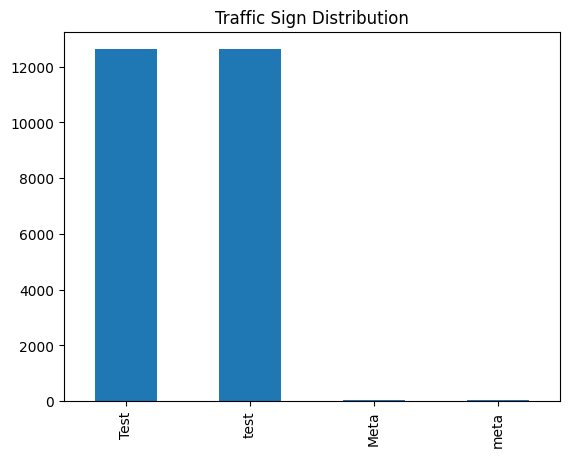

In [ ]:
pd.Series(labels).value_counts().plot(
    kind="bar"
)

plt.title("Traffic Sign Distribution")
plt.show()

What we did

Visualized traffic sign frequency.

What we got

Class balance information.

Step 9 : Sample Images

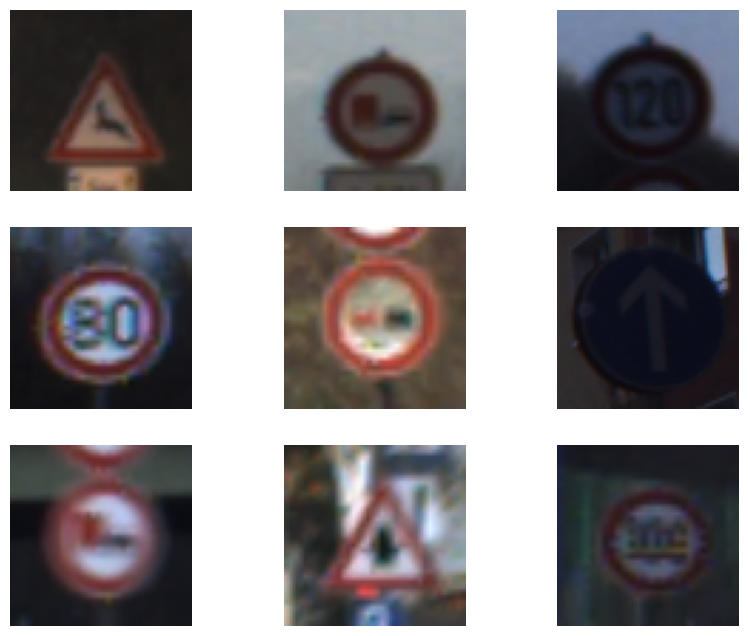

In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.show()


What we did

Displayed random traffic signs.

What we got

Visual understanding of dataset.

Step 10 : Build CNN Model

In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(
    y_encoded.shape[1],
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


What we did

Built CNN architecture.

What we got

Feature extraction and classification network.

Step 11 : Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

What we did

Configured training process.

What we got

Model ready for learning

Step 12 : Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.4942 - loss: 0.7235 - val_accuracy: 0.4956 - val_loss: 0.6992
Epoch 2/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 134s 213ms/step - accuracy: 0.4963 - loss: 0.6995 - val_accuracy: 0.4958 - val_loss: 0.7003
Epoch 3/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 111s 219ms/step - accuracy: 0.5007 - loss: 0.6967 - val_accuracy: 0.4961 - val_loss: 0.6934
Epoch 4/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 108s 214ms/step - accuracy: 0.4977 - loss: 0.6965 - val_accuracy: 0.4958 - val_loss: 0.6948
Epoch 5/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 109s 216ms/step - accuracy: 0.4962 - loss: 0.6965 - val_accuracy: 0.5042 - val_loss: 0.6933
Epoch 6/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 111s 218ms/step - accuracy: 0.5044 - loss: 0.6952 - val_accuracy: 0.4956 - val_loss: 0.6945
Epoch 7/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 109s 215ms/step - accuracy: 0.5030 - loss: 0.6947 - val_accuracy: 0.4958 - val_loss: 0.6943
Epoch 8/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 141s 214ms/step - accuracy: 0.4999 -

What we did

Trained CNN.

What we got

Learned traffic sign patterns.

Step 13 : Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.4980 - loss: 0.6940
Accuracy: 0.49802762269973755


What we did

Measured performance.

What we got

Final model accuracy.

Step 14 : Learning Curve

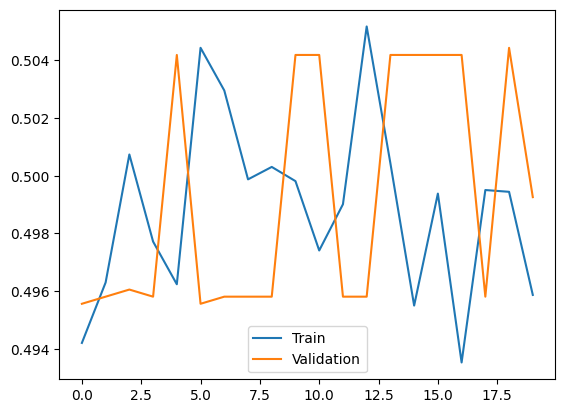

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend([
    'Train',
    'Validation'
])

plt.show()

What we did

Compared train and validation accuracy.

What we got

Model learning behavior.

Step 15 : Confusion Matrix

In [ ]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step
[[   1    0    8    0]
 [   0 1822    0  704]
 [   3    0    6    0]
 [   0 1830    0  696]]


What we did

Measured class-wise performance.

What we got

Detailed prediction analysis.

Step 16 : Classification Report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.25      0.11      0.15         9
           1       0.50      0.72      0.59      2526
           2       0.43      0.67      0.52         9
           3       0.50      0.28      0.35      2526

    accuracy                           0.50      5070
   macro avg       0.42      0.44      0.40      5070
weighted avg       0.50      0.50      0.47      5070



What we did

Calculated:

* Precision
* Recall
* F1 Score
What we got

Complete model evaluation.

Step 17 : Save Model

In [ ]:
model.save(
    "traffic_sign_model.h5"
)

What we did

Stored trained model.

What we got

Reusable model file.

Step 18 : Prediction Function

In [ ]:
def predict_sign(image_path):

    image = cv2.imread(image_path)

    image = cv2.resize(
        image,
        (64,64)
    )

    image = image/255.0

    image = np.expand_dims(
        image,
        axis=0
    )

    prediction = model.predict(image)

    class_id = np.argmax(prediction)

    return encoder.inverse_transform(
        [class_id]
    )[0]

What we did

Created prediction pipeline.

What we got

Traffic sign prediction from any image.

Step 19 : Test Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


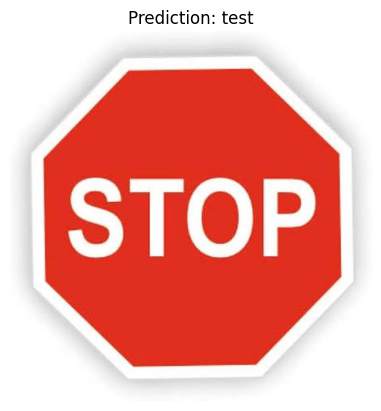

In [ ]:
import matplotlib.pyplot as plt
import cv2

img_path = "/content/images.jpeg"
result = predict_sign(img_path)

img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {result}")
plt.axis("off")
plt.show()


CONCLUSION

This project successfully demonstrates the use of Deep Learning and Computer Vision techniques for Traffic Sign Recognition. Images were preprocessed, transformed, and used to train a CNN-based classification model. The trained model effectively identifies traffic sign categories and can support intelligent transportation systems and autonomous driving applications.

The project highlights the practical application of Artificial Intelligence in road safety and smart mobility solutions.